In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
input_path = f'/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/'

In [3]:
df = pd.read_csv(os.path.join(input_path, 'data/raw/train_FD001.txt'), sep=r"\s+", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
columns = ( ["engine_id", "cycle"] + [f"operational_setting_{i}" for i in range(1, 4)] + 
           [f"s{i}" for i in range(1, 22)])
df.columns = columns
df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
RUL_CAP = 125

max_cycles = ( df.groupby('engine_id')['cycle'].max().rename('max_cycle'))
df = df.join(max_cycles, on='engine_id') 
df['RUL'] = df['max_cycle'] - df['cycle']
df['RUL'] = df['RUL'].clip(upper = RUL_CAP)       #Cap RUL at RUL_CAP
df.drop(columns=['max_cycle'], inplace=True)
df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [6]:
df.shape

(20631, 27)

#### Missing values

In [7]:
df.isna().sum()

engine_id                0
cycle                    0
operational_setting_1    0
operational_setting_2    0
operational_setting_3    0
s1                       0
s2                       0
s3                       0
s4                       0
s5                       0
s6                       0
s7                       0
s8                       0
s9                       0
s10                      0
s11                      0
s12                      0
s13                      0
s14                      0
s15                      0
s16                      0
s17                      0
s18                      0
s19                      0
s20                      0
s21                      0
RUL                      0
dtype: int64

#### Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

#### Data type

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   engine_id              20631 non-null  int64  
 1   cycle                  20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   s1                     20631 non-null  float64
 6   s2                     20631 non-null  float64
 7   s3                     20631 non-null  float64
 8   s4                     20631 non-null  float64
 9   s5                     20631 non-null  float64
 10  s6                     20631 non-null  float64
 11  s7                     20631 non-null  float64
 12  s8                     20631 non-null  float64
 13  s9                     20631 non-null  float64
 14  s10                    20631 non-null  float64
 15  s1

#### Unique numbers

In [10]:
df.nunique()

engine_id                 100
cycle                     362
operational_setting_1     158
operational_setting_2      13
operational_setting_3       1
s1                          1
s2                        310
s3                       3012
s4                       4051
s5                          1
s6                          2
s7                        513
s8                         53
s9                       6403
s10                         1
s11                       159
s12                       427
s13                        56
s14                      6078
s15                      1918
s16                         1
s17                        13
s18                         1
s19                         1
s20                       120
s21                      4745
RUL                       126
dtype: int64

#### Dataset statistics 


In [11]:
df.describe()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,86.829286
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251,41.673699
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,125.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,125.000000


#### Data categories

In [12]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 27 numerical features : ['engine_id', 'cycle', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 'RUL']

We have 0 categorical features : []


In [13]:
np.random.seed(42)

## Visualization

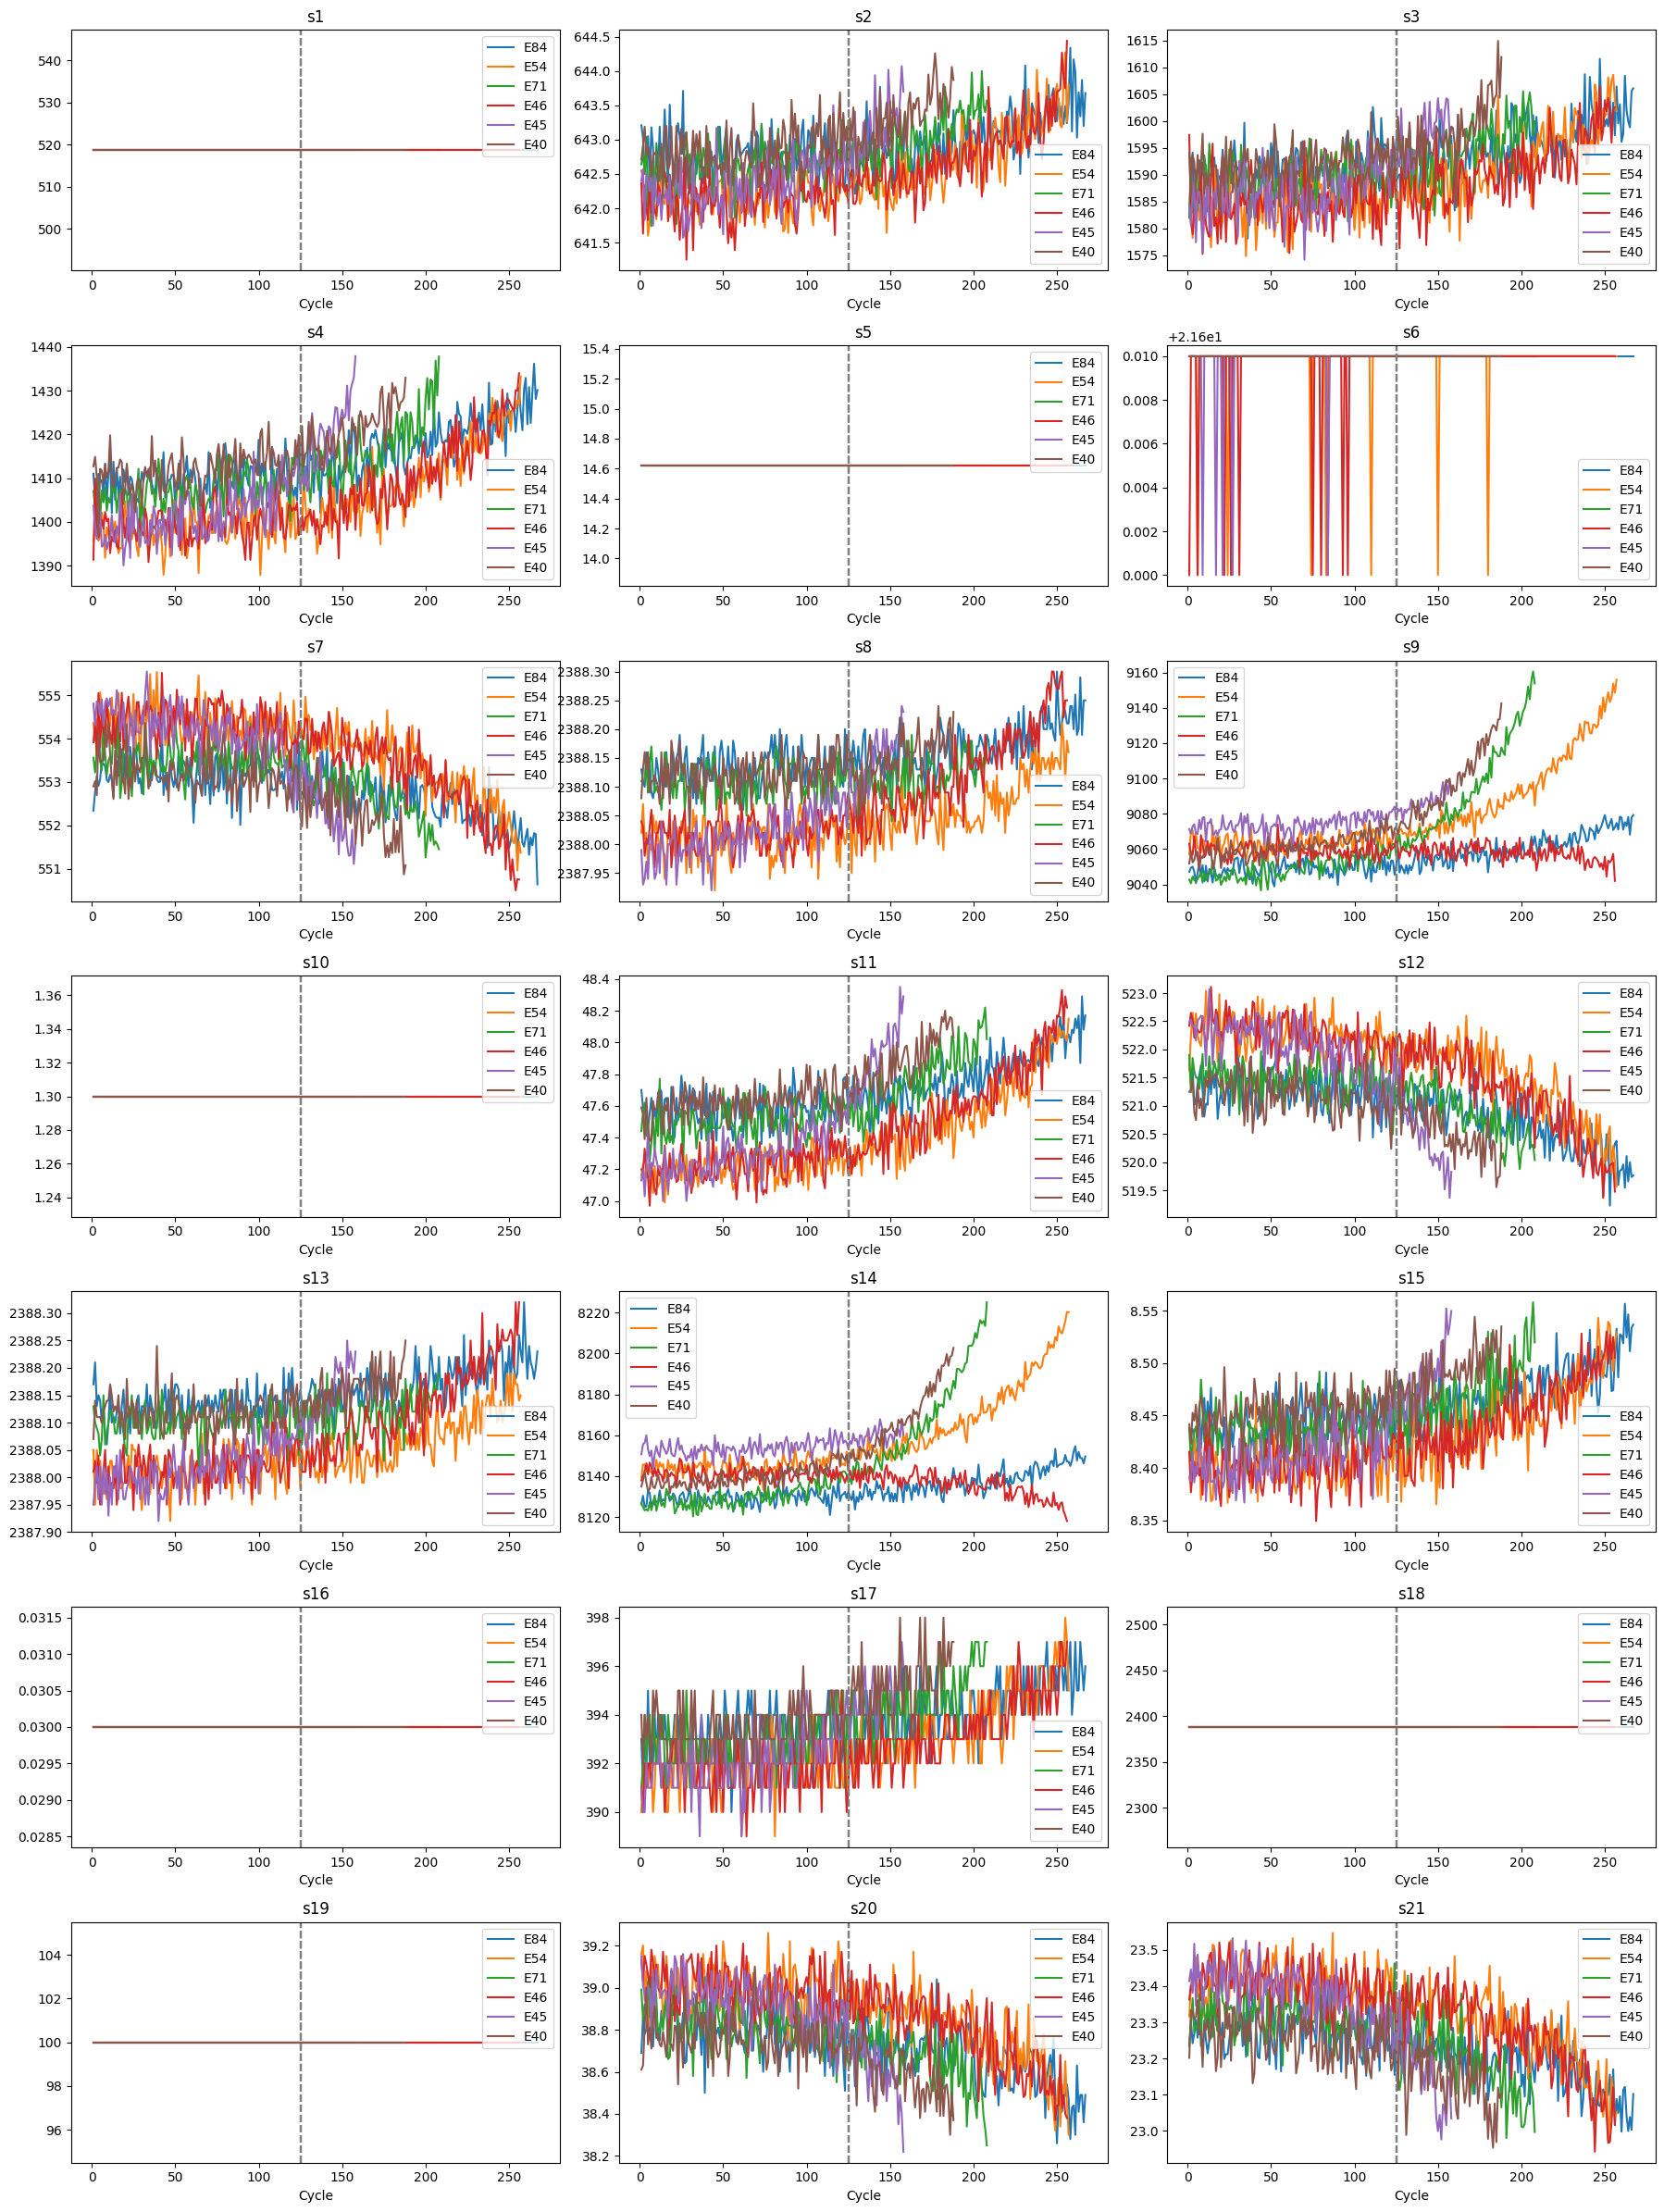

In [14]:
sample_engines = np.random.choice(df["engine_id"].unique(),size=6,replace=False)
df_plot = df[df["engine_id"].isin(sample_engines)]

fig, axes = plt.subplots(nrows=7,ncols=3,figsize=(18, 24), sharex=False)
axes = axes.flatten()
for i, sensor in enumerate([f"s{i}" for i in range(1,22)]):
    ax = axes[i]
    for engine in sample_engines:
        temp = df_plot[df_plot["engine_id"] == engine]
        ax.plot(temp["cycle"], temp[sensor], label=f"E{engine}")
        ax.set_xlabel('Cycle')
        ax.axvline(x = 125, linestyle = '--', color = 'grey')
        ax.legend()
    ax.set_title(sensor)

plt.tight_layout()
plt.show()

#### Univariate Analysis - Probability Distributions

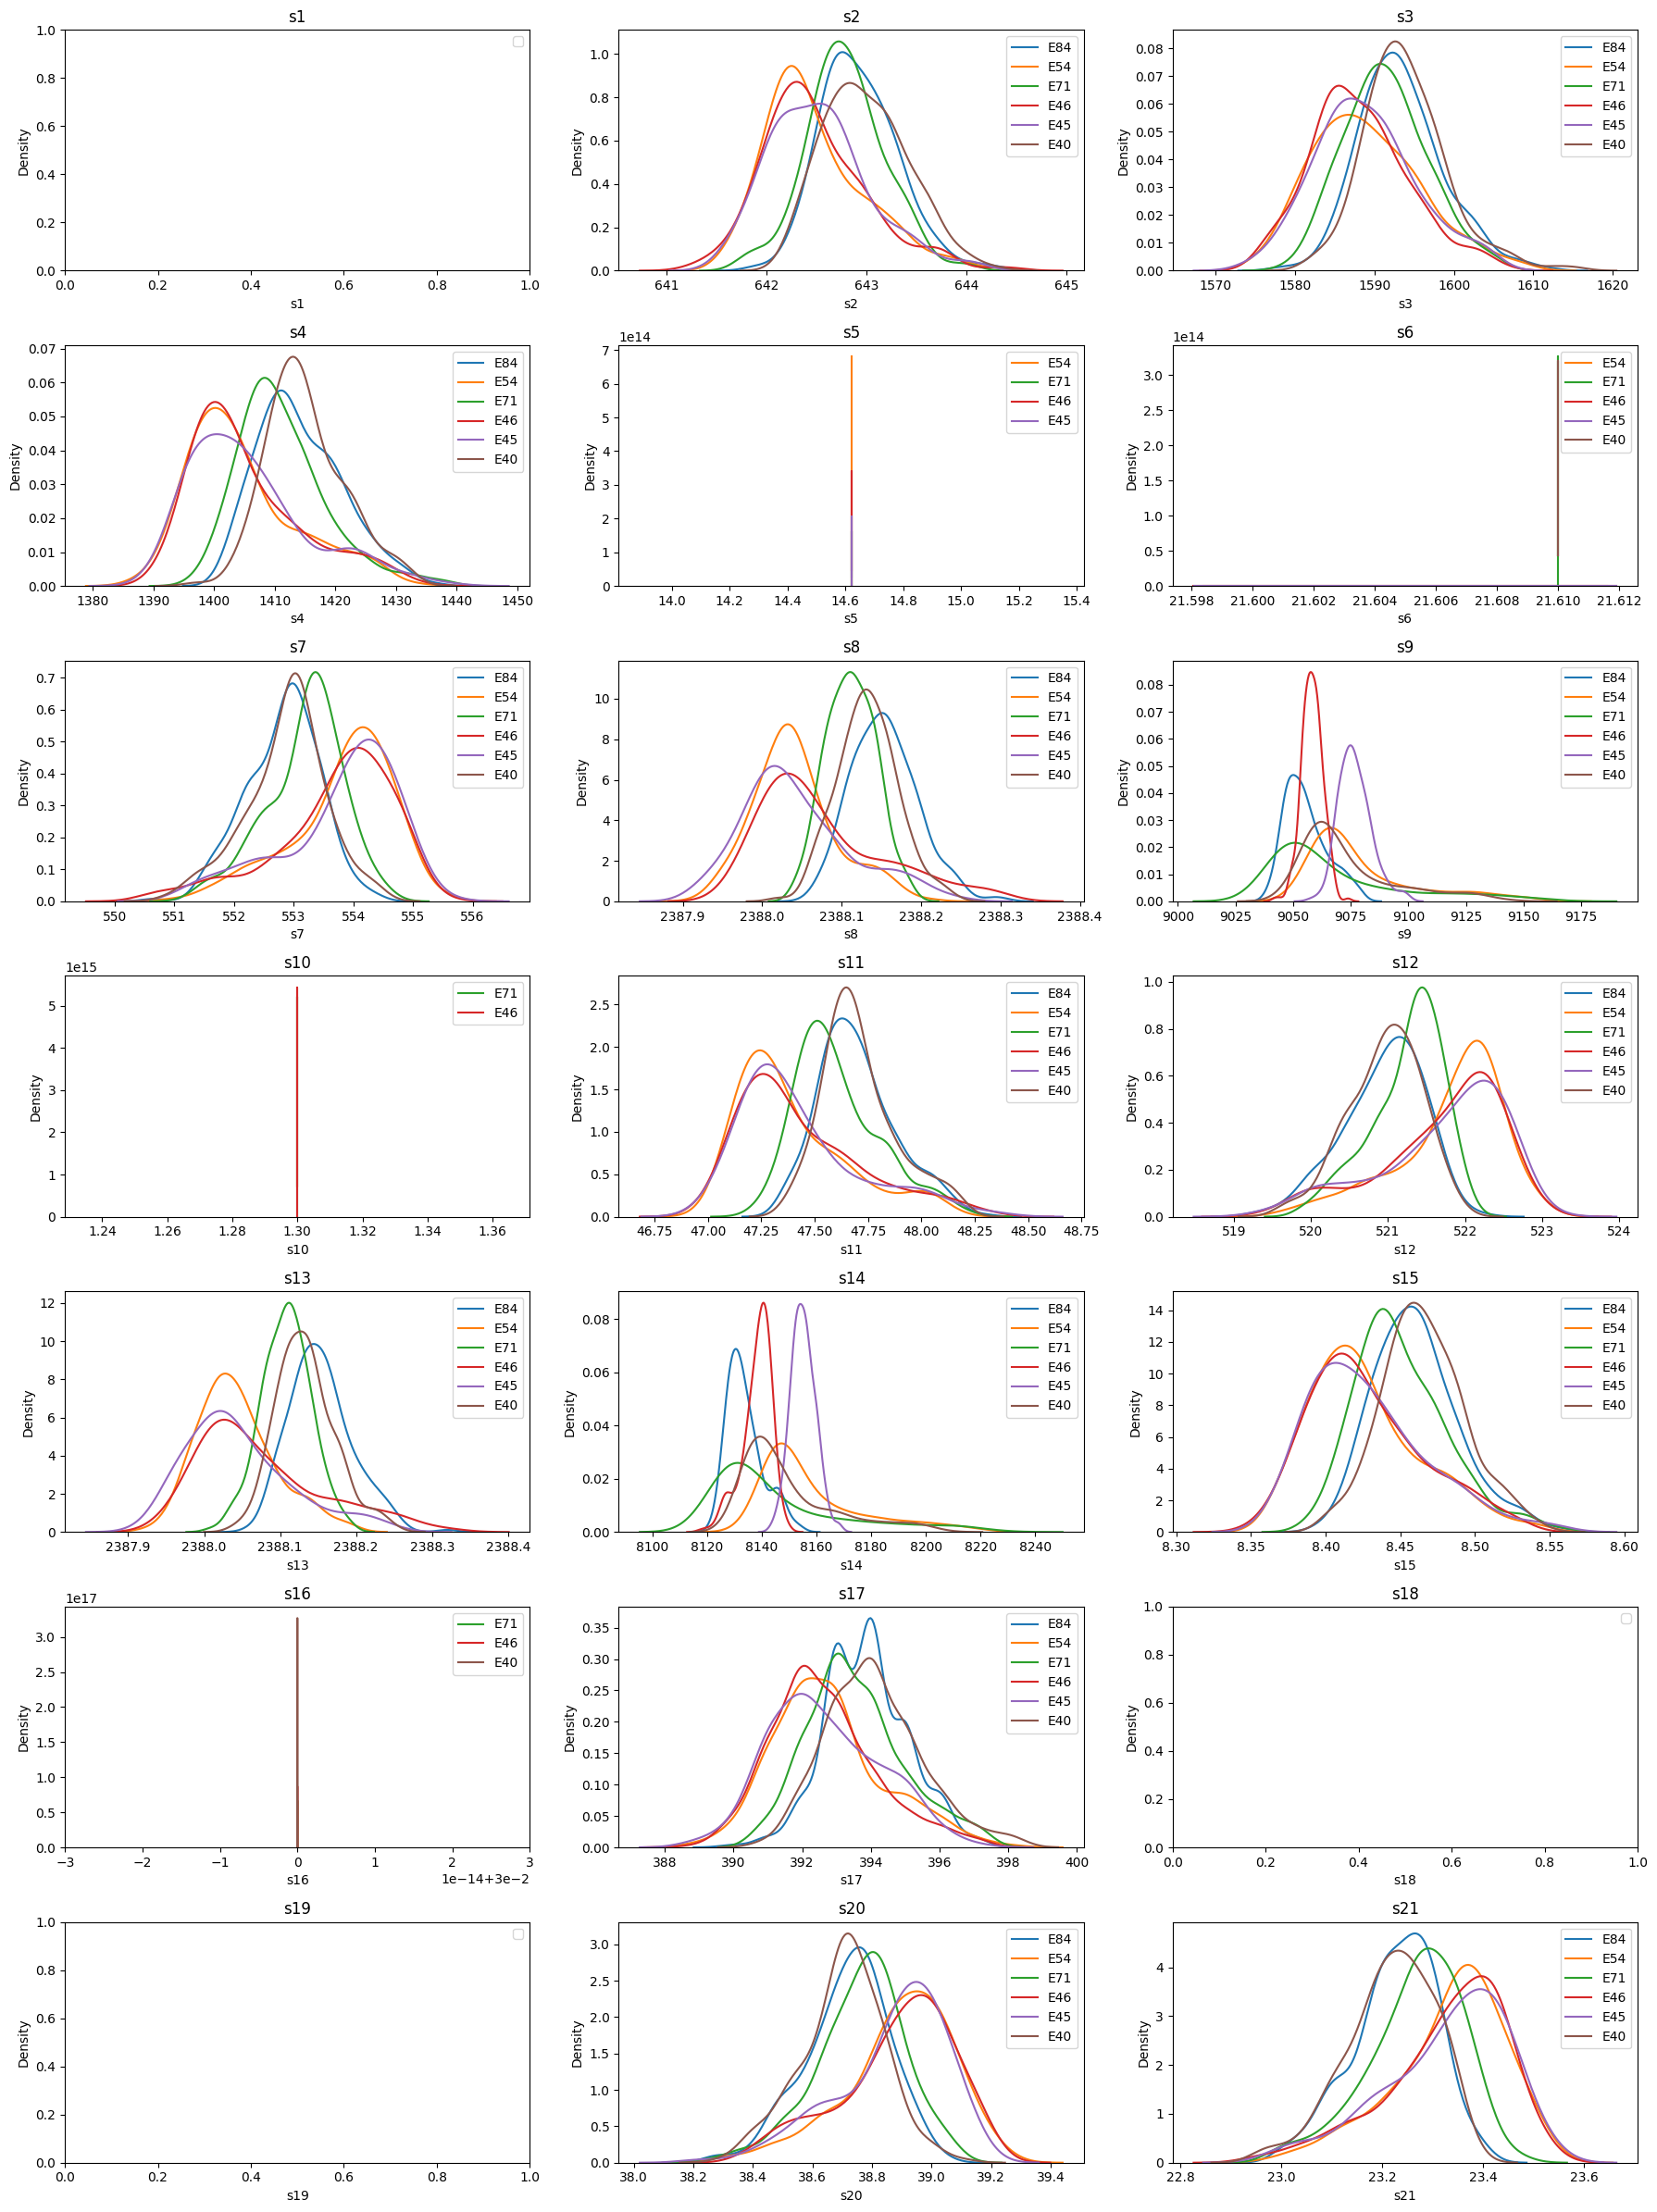

In [15]:
fig, axes = plt.subplots(7, 3, figsize=(18,24))

axes = axes.flatten()
for i, sensor in enumerate([f"s{i}" for i in range(1,22)]):
    ax = axes[i]
    for engine in sample_engines:
        temp = df[df["engine_id"] == engine]
        sns.kdeplot(temp[sensor],ax=ax,label=f"E{engine}")
        ax.legend()
    ax.set_title(sensor)
    #ax.set_title(f"Engine {engine}")

plt.tight_layout()
plt.show()

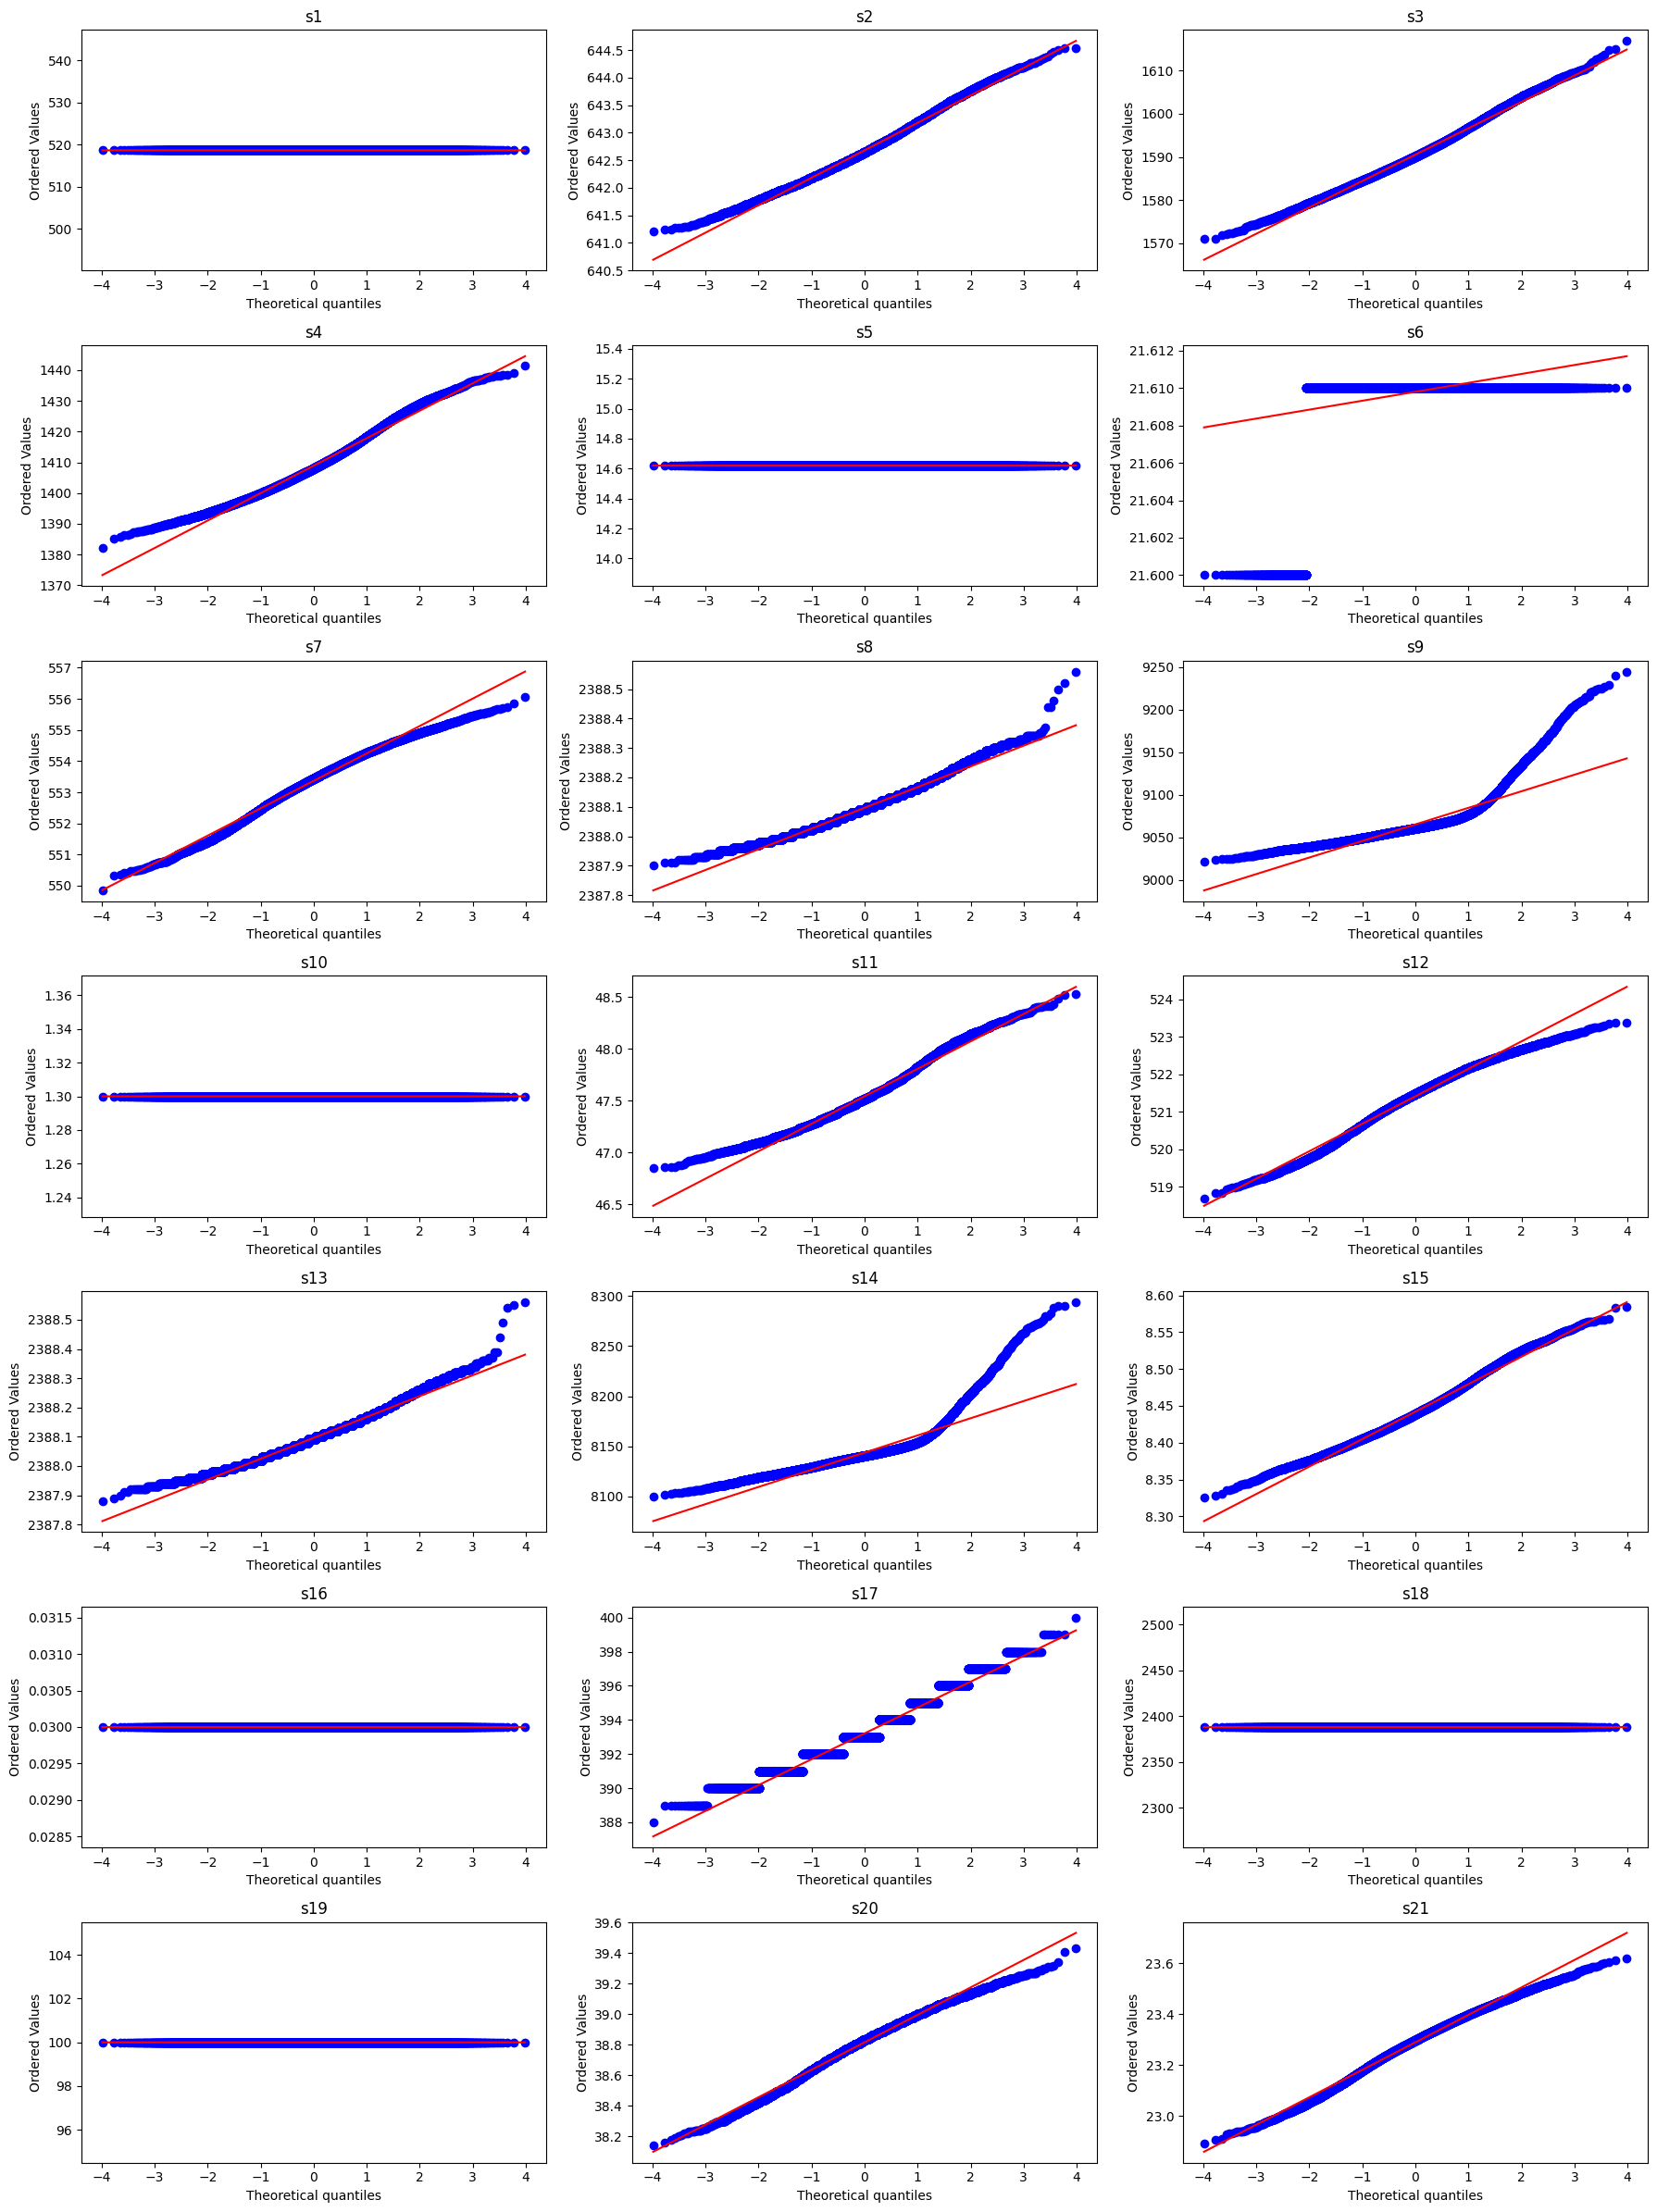

In [16]:
from scipy.stats import probplot

fig, axes = plt.subplots(7,3, figsize=(18,24))
axes = axes.flatten()
for i, sensor in enumerate([f"s{i}" for i in range(1,22)]):
    probplot((df[sensor]), dist="norm", plot=axes[i])
    axes[i].set_title(sensor)

plt.tight_layout()
plt.show()

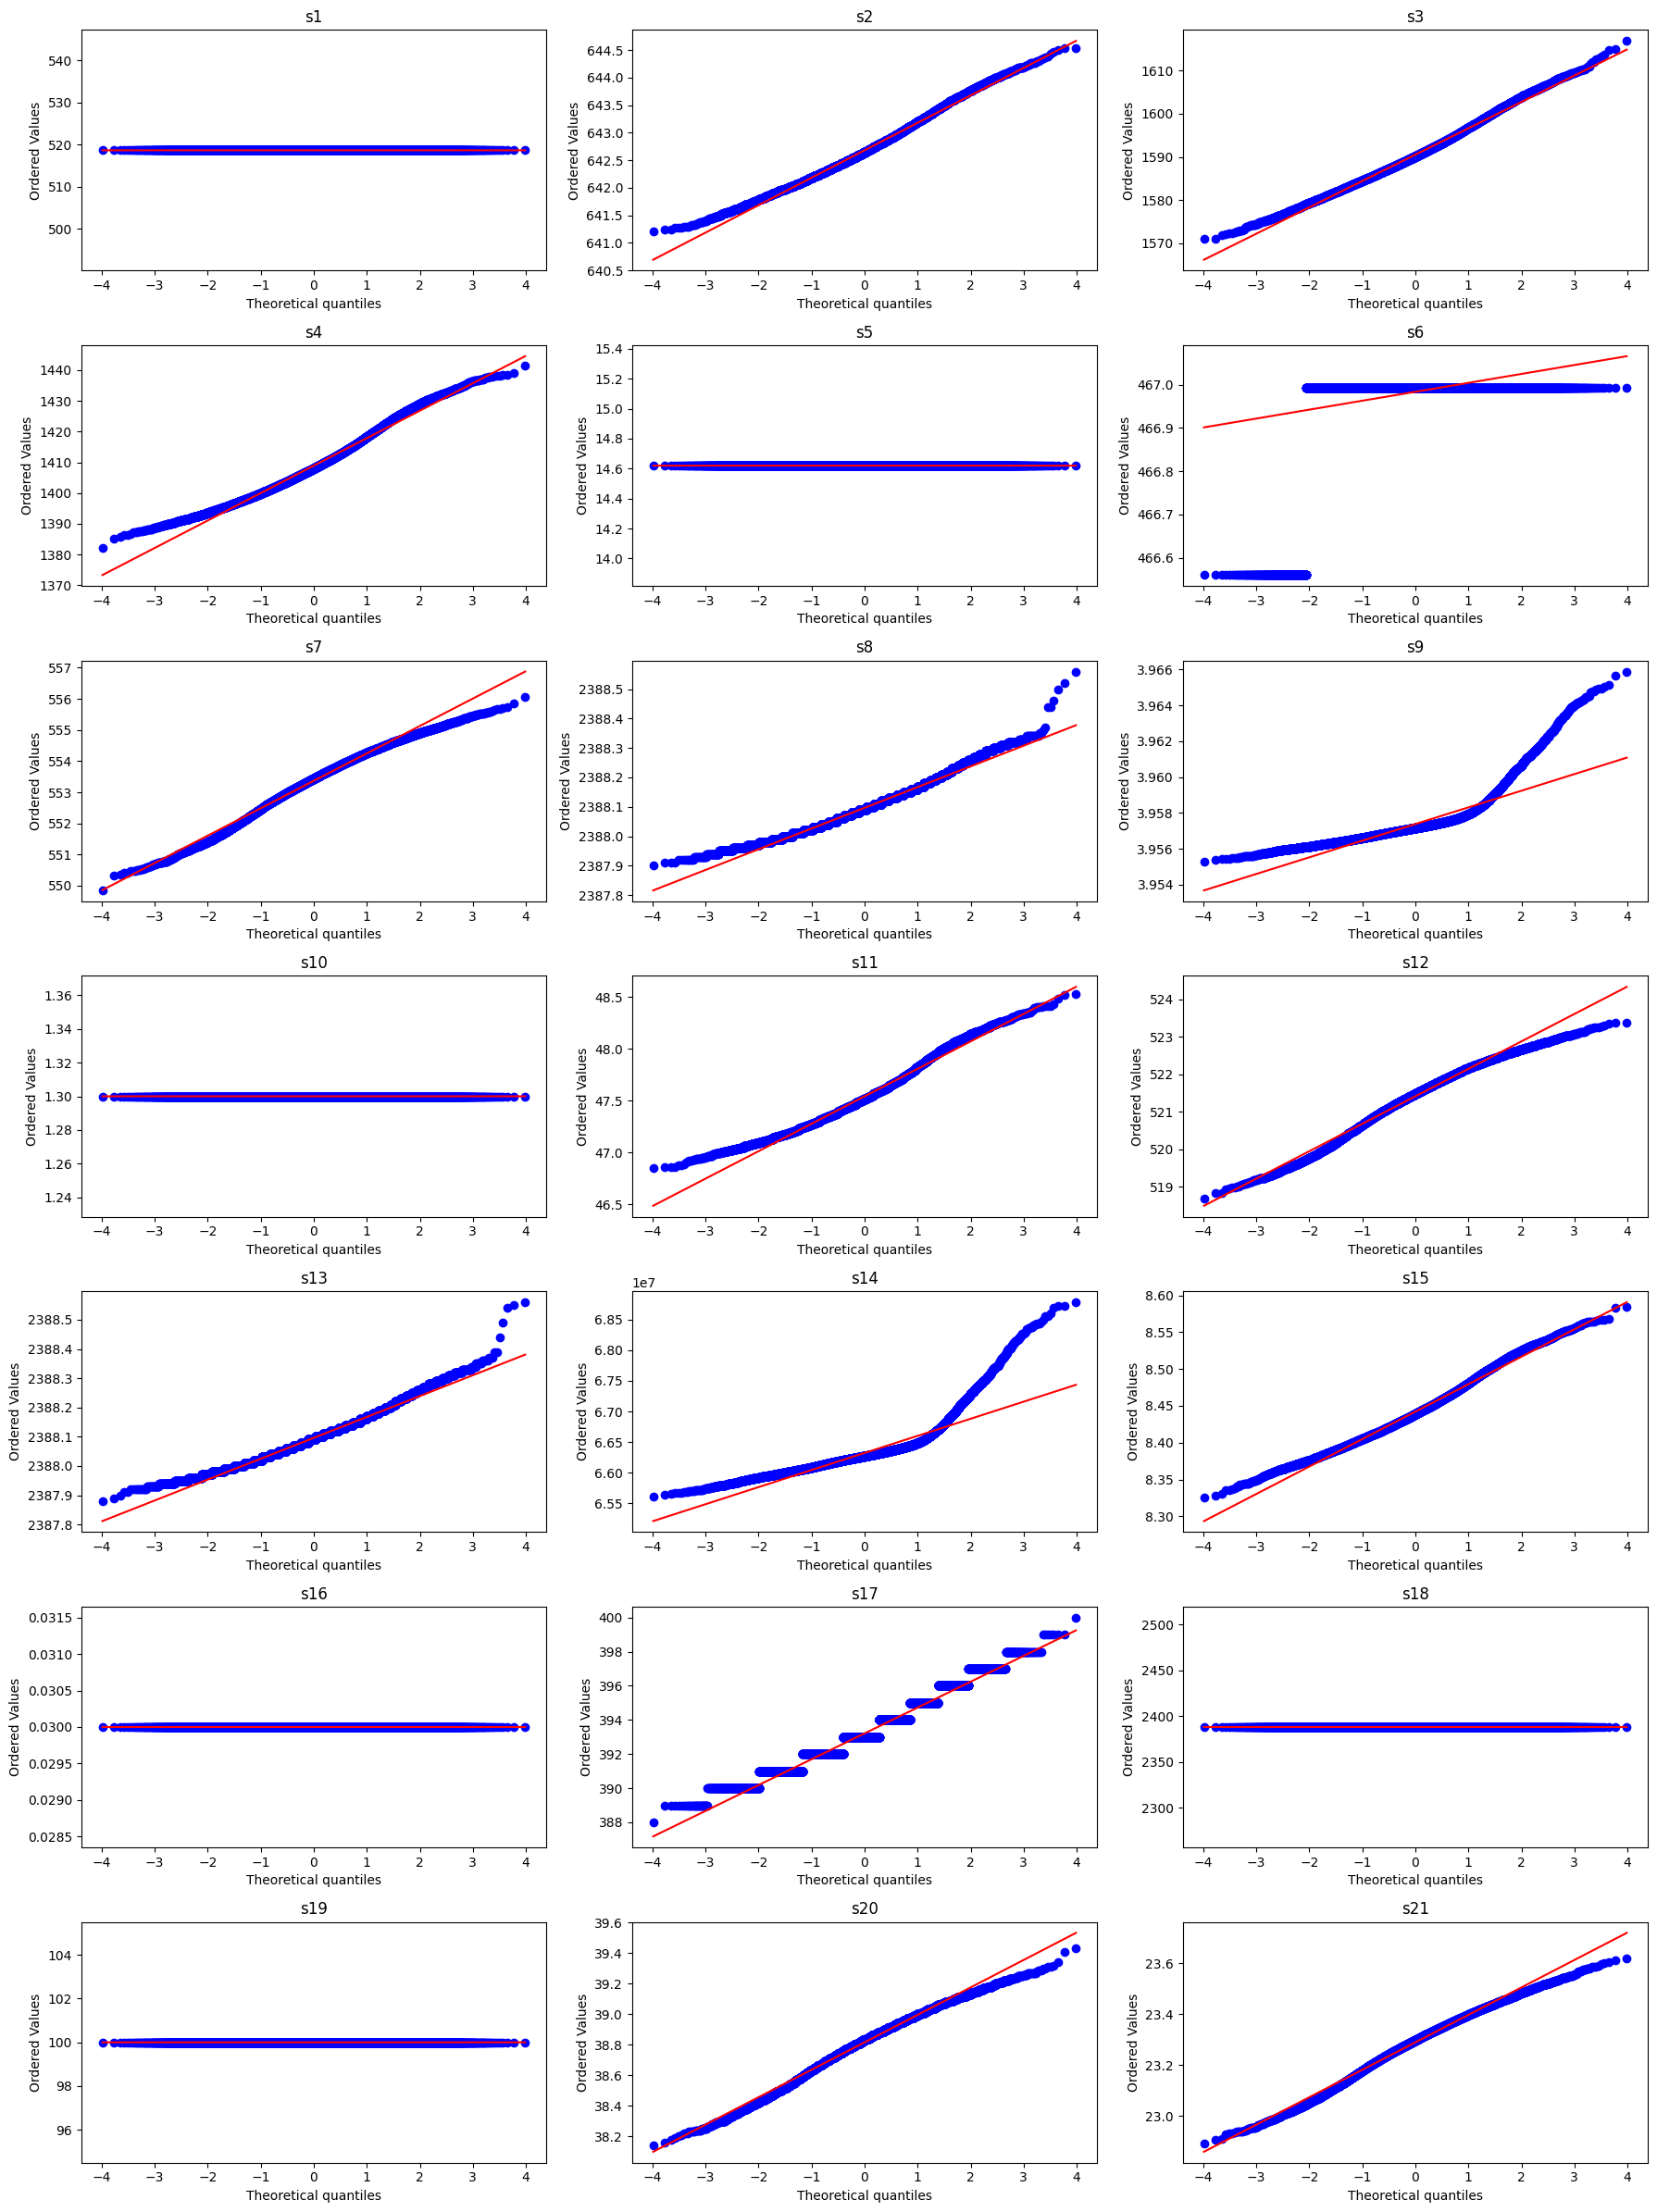

In [17]:
columns = ( ["engine_id", "cycle"] + 
           [f"s{i}" for i in range(1, 22)])

df_refined = df.copy()
df_refined['s6'] = (df['s6'])**2
df_refined['s9'] = np.log10(df['s9'])
df_refined['s14'] = df['s14']**2

fig, axes = plt.subplots(7,3, figsize=(18,24))
axes = axes.flatten()
for i, sensor in enumerate([f"s{i}" for i in range(1,22)]):
    probplot((df_refined[sensor]), dist="norm", plot=axes[i])
    axes[i].set_title(sensor)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import (shapiro, normaltest)
normality_results = []

sensor_col = [f"s{i}" for i in range(1,22)]
for sensor in sensor_col:
    data = df[sensor].dropna()

    # Shapiro is slow for huge samples
    sample = data.sample(min(5000, len(data)),random_state=42) 
    shapiro_stat, shapiro_p = shapiro(sample)

    dag_stat, dag_p = normaltest(data)

    normality_results.append({
        "sensor": sensor,
        "shapiro_p": shapiro_p,
        "dagostino_p": dag_p,
        "normal_shapiro": shapiro_p > 0.05,
        "normal_dagostino": dag_p > 0.05
    })

normality_df = pd.DataFrame(normality_results)
normality_df.sort_values("dagostino_p", ascending=False)

#If p > 0.05: Fail to reject normality.

,sensor,shapiro_p,dagostino_p,normal_shapiro,normal_dagostino
2,s3,3.536832e-13,6.919785e-69,False,False
1,s2,3.809623e-15,1.026406e-74,False,False
16,s17,3.242861e-37,6.821092e-89,False,False
20,s21,7.267582e-20,3.542589e-90,False,False
19,s20,8.864246e-20,9.073110e-94,False,False
14,s15,1.115492e-20,7.331040e-109,False,False
6,s7,1.807317e-21,2.533604e-114,False,False
11,s12,3.702320e-24,4.425619e-139,False,False
3,s4,2.496856e-23,6.755065e-141,False,False
10,s11,3.535879e-26,1.956443e-156,False,False


Notice that any of these transformed values are not changing anything. 

#### Multivariate Analysis

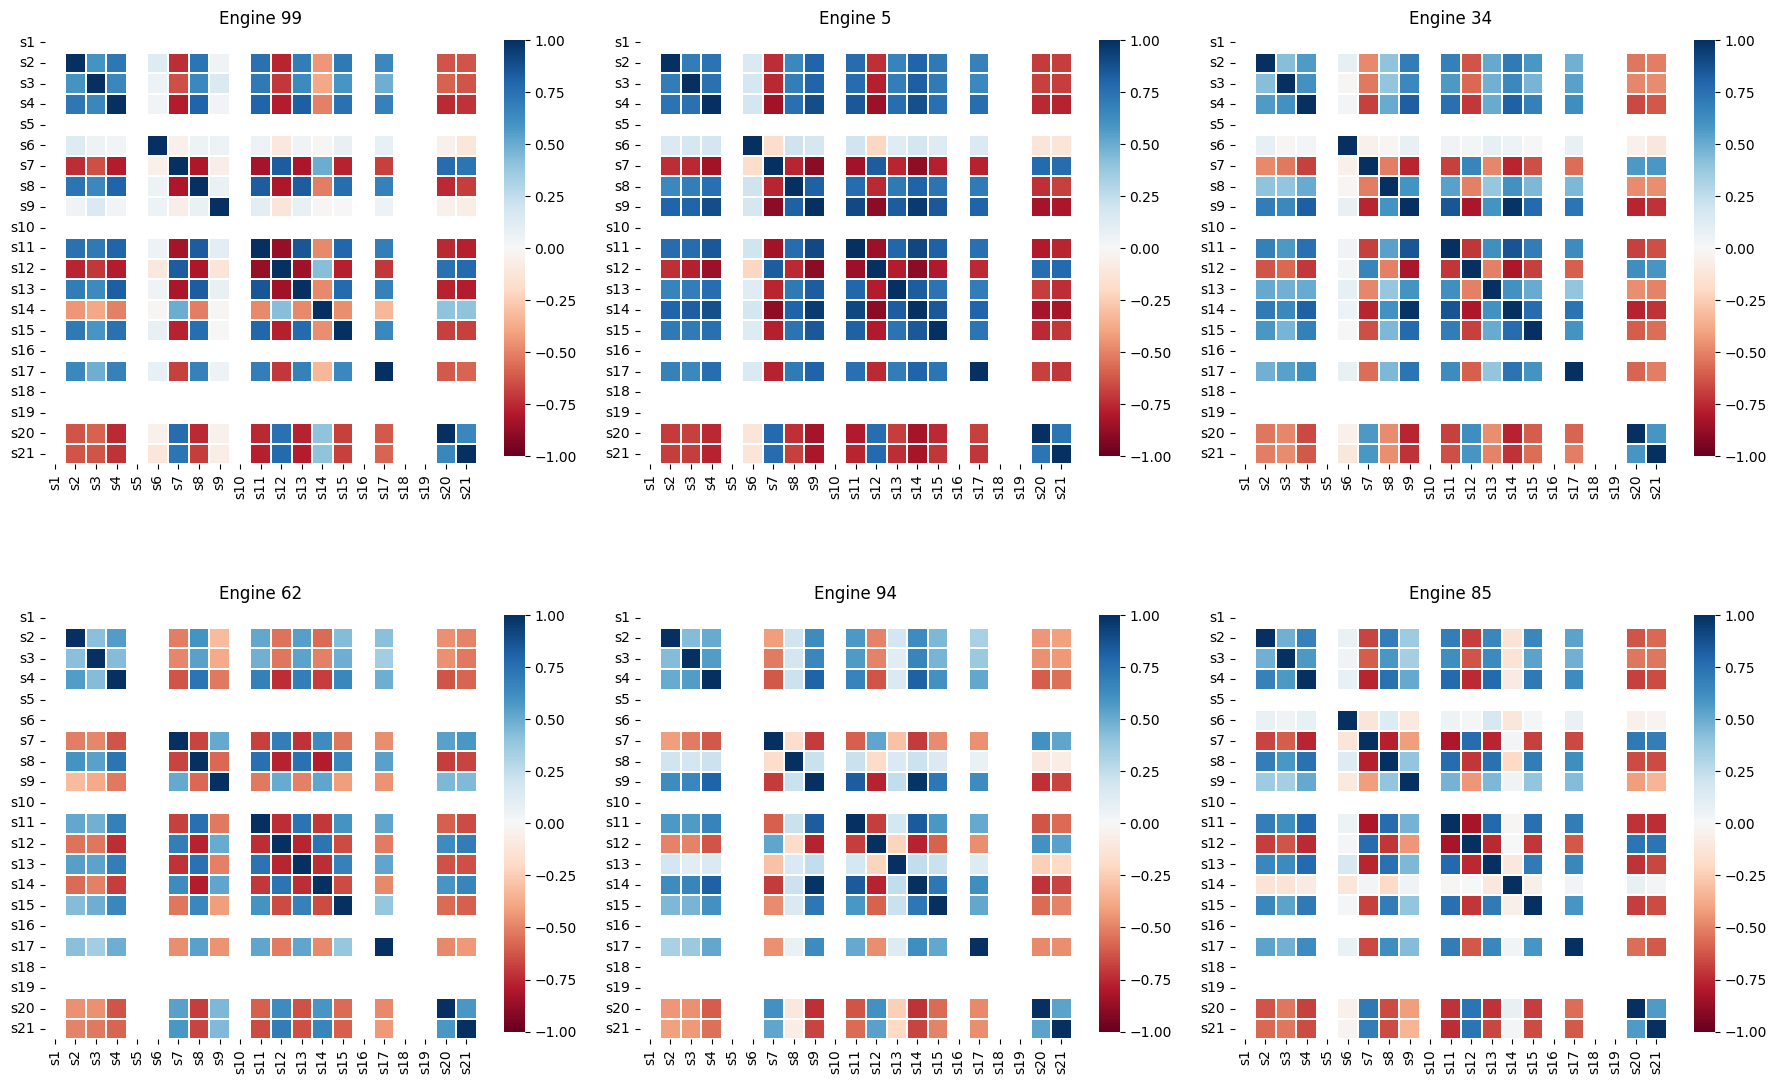

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(18, 12))

axes = axes.flatten()
for ax, engine in zip(axes, sample_engines):
    temp = df[df["engine_id"] == engine]
    corr_matrix = temp[[f"s{i}" for i in range(1, 22)]].corr()

    sns.heatmap(corr_matrix, cmap='RdBu', center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.3, cbar_kws={'shrink': 0.7})

    ax.set_title(f"Engine {engine}")
    
plt.tight_layout()
plt.show()

## Finding number of components necessary to explain 95% of variance with PCA

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[sensor_col])
pca = PCA()
pca.fit(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Number of PCA components to explain 90% variance: {n_components_90}')
print(f'Number of PCA components to explain 95% variance: {n_components_95}')

Number of PCA components to explain 90% variance: 7
Number of PCA components to explain 95% variance: 10


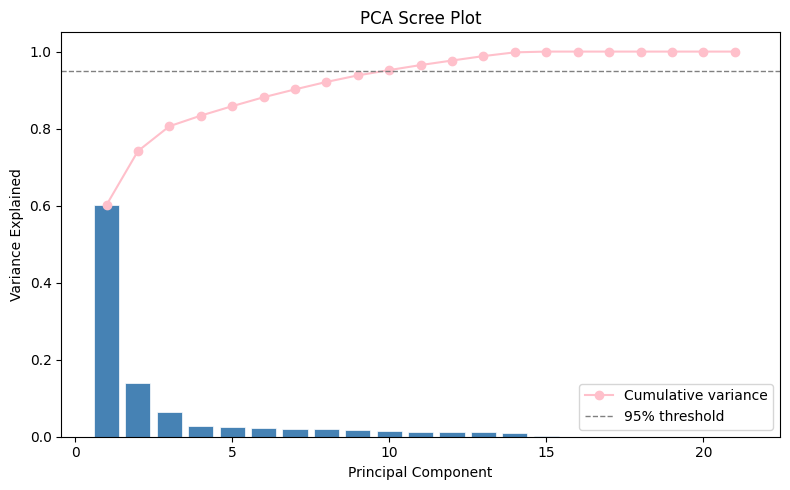

In [27]:
#Scree plot
fig, ax = plt.subplots(figsize=(8, 5))
components = np.arange(1, len(explained_variance_ratio) + 1)
ax.bar(components, explained_variance_ratio, color='steelblue', edgecolor='white', linewidth=0.5)
ax.plot(components, cumulative_variance, color='pink', marker='o', label='Cumulative variance')
ax.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.show()